<a href="https://colab.research.google.com/github/sangeetha457/sangeetha/blob/main/youtube.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark

In [2]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

In [3]:
import os

In [4]:
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

In [5]:
from pyspark.sql import SparkSession

In [6]:
spark = SparkSession.builder.appName("YouTubeChannelAnalysis").getOrCreate()

In [7]:
from google.colab import drive

In [8]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
file_path = '/content/drive/MyDrive/top-5000-youtube-channels.csv'

In [10]:
df = spark.read.csv(file_path, header=True, inferSchema=True)

In [11]:
df.printSchema()

root
 |-- Rank: string (nullable = true)
 |-- Grade: string (nullable = true)
 |-- Channel name: string (nullable = true)
 |-- Video Uploads: string (nullable = true)
 |-- Subscribers: string (nullable = true)
 |-- Video views: long (nullable = true)



In [12]:
df.show(5)

+----+-----+--------------------+-------------+-----------+-----------+
|Rank|Grade|        Channel name|Video Uploads|Subscribers|Video views|
+----+-----+--------------------+-------------+-----------+-----------+
| 1st| A++ |              Zee TV|        82757|   18752951|20869786591|
| 2nd| A++ |            T-Series|        12661|   61196302|47548839843|
| 3rd| A++ |Cocomelon - Nurse...|          373|   19238251| 9793305082|
| 4th| A++ |           SET India|        27323|   31180559|22675948293|
| 5th| A++ |                 WWE|        36756|   32852346|26273668433|
+----+-----+--------------------+-------------+-----------+-----------+
only showing top 5 rows



In [13]:
print("Total Rows:", df.count())
print("Columns:", df.columns)

Total Rows: 5000
Columns: ['Rank', 'Grade', 'Channel name', 'Video Uploads', 'Subscribers', 'Video views']


In [14]:
from pyspark.sql.functions import col, isnan, when, count

In [15]:
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

+----+-----+------------+-------------+-----------+-----------+
|Rank|Grade|Channel name|Video Uploads|Subscribers|Video views|
+----+-----+------------+-------------+-----------+-----------+
|   0|    0|           0|            0|          0|          0|
+----+-----+------------+-------------+-----------+-----------+



In [16]:
df_cleaned = df.dropna()

In [19]:
df_cleaned.orderBy(col("subscribers").desc()).select("Channel name","subscribers").show(10)

+---------------------------+-----------+
|               Channel name|subscribers|
+---------------------------+-----------+
|                    BIGBANG|    9998464|
|       Doggy Doggy Play ...|    9994112|
|                  DrakeVEVO|    9987454|
|               ExzoticSlice|      99785|
|       HooplaKidz Franҫa...|     997671|
|             MrSuicideSheep|    9972603|
|        Dutch Lady Việt Nam|      99646|
|자동차 & 로봇 장난감 Car &…|     996142|
|               westlifeVEVO|     995868|
|              Pablo Oficial|     995155|
+---------------------------+-----------+
only showing top 10 rows



In [21]:
df_cleaned.groupBy("Grade").count().orderBy(col("count").desc()).show(10)

+-----+-----+
|Grade|count|
+-----+-----+
|  B+ | 2956|
|  A- | 1024|
|   A |  963|
|  A+ |   41|
| A++ |   10|
|     |    6|
+-----+-----+



In [24]:
from pyspark.sql.functions import avg

In [25]:
df_cleaned.groupBy("Grade").agg(avg("subscribers")).orderBy("avg(subscribers)", ascending=False).show(10)

+-----+------------------+
|Grade|  avg(subscribers)|
+-----+------------------+
| A++ |      2.22817625E7|
|  A+ |    1.1726947475E7|
|   A | 5107136.294314382|
|  A- |2798520.3751328373|
|  B+ |1535207.9470977222|
|     |          279529.0|
+-----+------------------+



In [26]:
import pandas as pd


In [27]:
import matplotlib.pyplot as plt

In [28]:
top_categories = df_cleaned.groupBy("Grade").count().orderBy("count", ascending=False).toPandas()

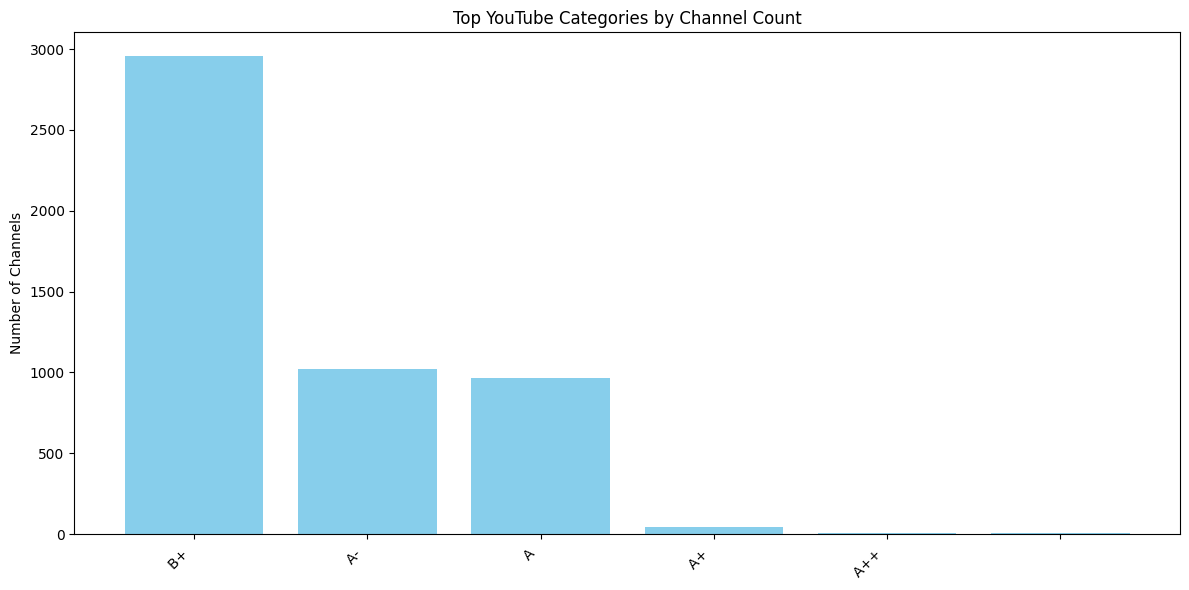

In [29]:
plt.figure(figsize=(12,6))
plt.bar(top_categories["Grade"], top_categories["count"], color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.title("Top YouTube Categories by Channel Count")
plt.ylabel("Number of Channels")
plt.tight_layout()
plt.show()